<a href="https://colab.research.google.com/github/Tharun1823/Parametric-Curve-Optimization/blob/main/parametric_curve_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Upload the CSV file**


In [1]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving xy_data.csv to xy_data.csv

Uploaded files:
xy_data.csv


**Install libraries**

In [2]:
!pip install -q numpy pandas matplotlib scipy

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, minimize
from scipy.spatial import cKDTree


**find and load the CSV**

In [4]:
import os
import glob

csv_files = glob.glob("*.csv")

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found. Please upload xy_data.csv")

print("CSV files found:", csv_files)

csv_file = csv_files[0]

data = pd.read_csv(csv_file)

print("\nUsing file:", csv_file)
print("\nFirst 5 rows:")
print(data.head())

print("\nDataset shape:", data.shape)
print("\nColumns:", data.columns.tolist())

CSV files found: ['xy_data.csv']

Using file: xy_data.csv

First 5 rows:
            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340

Dataset shape: (1500, 2)

Columns: ['x', 'y']


**Extract X and Y data**

In [5]:
data.columns = [col.strip().lower() for col in data.columns]

if "x" not in data.columns or "y" not in data.columns:
    raise ValueError(
        f"Expected columns named 'x' and 'y'. Found: {data.columns.tolist()}"
    )

points = data[["x", "y"]].dropna().to_numpy()

print("Number of valid points:", len(points))
print("\nFirst 10 points:")
print(points[:10])

Number of valid points: 1500

First 10 points:
[[ 88.364456  57.784378]
 [ 74.283936  54.40678 ]
 [ 60.256474  46.311462]
 [ 82.13437   57.717567]
 [101.03639   67.84934 ]
 [ 69.284134  48.406086]
 [ 77.81013   57.588833]
 [ 91.29688   63.03135 ]
 [107.66841   65.91405 ]
 [ 76.40689   56.871525]]


**Plot the given data**

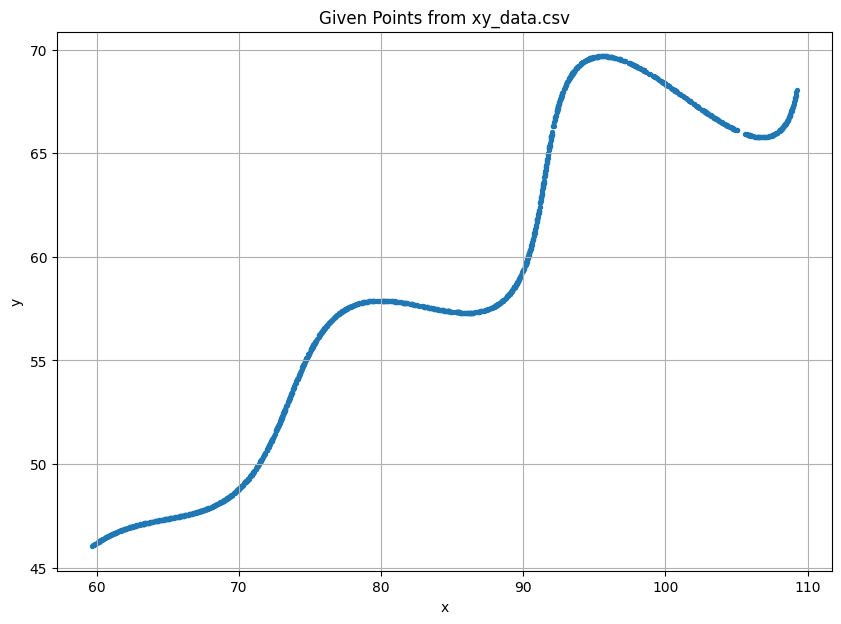

In [6]:
plt.figure(figsize=(10, 7))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=8
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Given Points from xy_data.csv")
plt.grid(True)

plt.show()

**Define the parametric curve**

In [8]:
def generate_curve(theta, M, X, n_points=8000):
    """
    Generate uniformly sampled points on the parametric curve.

    Parameters
    ----------
    theta : float
        Rotation angle in radians.

    M : float
        Exponential coefficient.

    X : float
        Horizontal translation.

    n_points : int
        Number of uniformly sampled t values.
    """

    t = np.linspace(6, 60, n_points)

    exponential_part = np.exp(M * np.abs(t))
    sine_part = np.sin(0.3 * t)

    x = (
        t * np.cos(theta)
        - exponential_part * sine_part * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + exponential_part * sine_part * np.cos(theta)
    )

    return np.column_stack((x, y))

**Define the L1 distance loss**

In [9]:
def loss_function(parameters):

    theta, M, X = parameters

    # Generate predicted curve
    predicted_curve = generate_curve(
        theta,
        M,
        X,
        n_points=8000
    )

    # Create nearest-neighbor search tree
    tree = cKDTree(predicted_curve)

    # Find nearest predicted point for every actual point
    distances, indices = tree.query(points)

    nearest_points = predicted_curve[indices]

    # L1 / Manhattan distance
    l1_distances = np.sum(
        np.abs(points - nearest_points),
        axis=1
    )

    # Mean L1 distance
    mean_l1 = np.mean(l1_distances)

    return mean_l1

**Define the assignment parameter bounds**

In [10]:
theta_min = 0
theta_max = np.deg2rad(50)

bounds = [
    (theta_min, theta_max),  # theta
    (-0.05, 0.05),           # M
    (0, 100)                 # X
]

print("Theta range (radians):", theta_min, "to", theta_max)
print("Theta range (degrees):", 0, "to", 50)
print("M range:", -0.05, "to", 0.05)
print("X range:", 0, "to", 100)

Theta range (radians): 0 to 0.8726646259971648
Theta range (degrees): 0 to 50
M range: -0.05 to 0.05
X range: 0 to 100


**Run global optimization**

In [11]:
print("Starting optimization...")

result = differential_evolution(
    func=loss_function,
    bounds=bounds,
    strategy="best1bin",
    maxiter=300,
    popsize=15,
    tol=1e-8,
    mutation=(0.5, 1.0),
    recombination=0.7,
    seed=42,
    polish=True,
    updating="immediate"
)

print("\nOptimization completed!")

Starting optimization...

Optimization completed!


**Fine-tune the result**

In [12]:
local_result = minimize(
    loss_function,
    result.x,
    method="Nelder-Mead",
    options={
        "maxiter": 1000,
        "xatol": 1e-10,
        "fatol": 1e-10
    }
)

# Use local result if it improved the loss
if local_result.fun < result.fun:
    best_parameters = local_result.x
    best_loss = local_result.fun
else:
    best_parameters = result.x
    best_loss = result.fun

**Print final optimized values**

In [13]:
theta, M, X = best_parameters

theta_degrees = np.degrees(theta)

print("=" * 60)
print("FINAL ESTIMATED PARAMETERS")
print("=" * 60)

print(f"\nTheta (radians) : {theta:.10f}")
print(f"Theta (degrees) : {theta_degrees:.10f} degrees")
print(f"M               : {M:.10f}")
print(f"X               : {X:.10f}")

print(f"\nMean L1 Distance: {best_loss:.12f}")

print("\n" + "=" * 60)

FINAL ESTIMATED PARAMETERS

Theta (radians) : 0.5235981308
Theta (degrees) : 29.9999630559 degrees
M               : 0.0299999909
X               : 55.0001208584

Mean L1 Distance: 0.002583543462



**Generate the optimized curve**

In [14]:
optimized_curve = generate_curve(
    theta,
    M,
    X,
    n_points=20000
)

print("Optimized curve generated.")

Optimized curve generated.


**Visualize dataset Vs optimized curve**

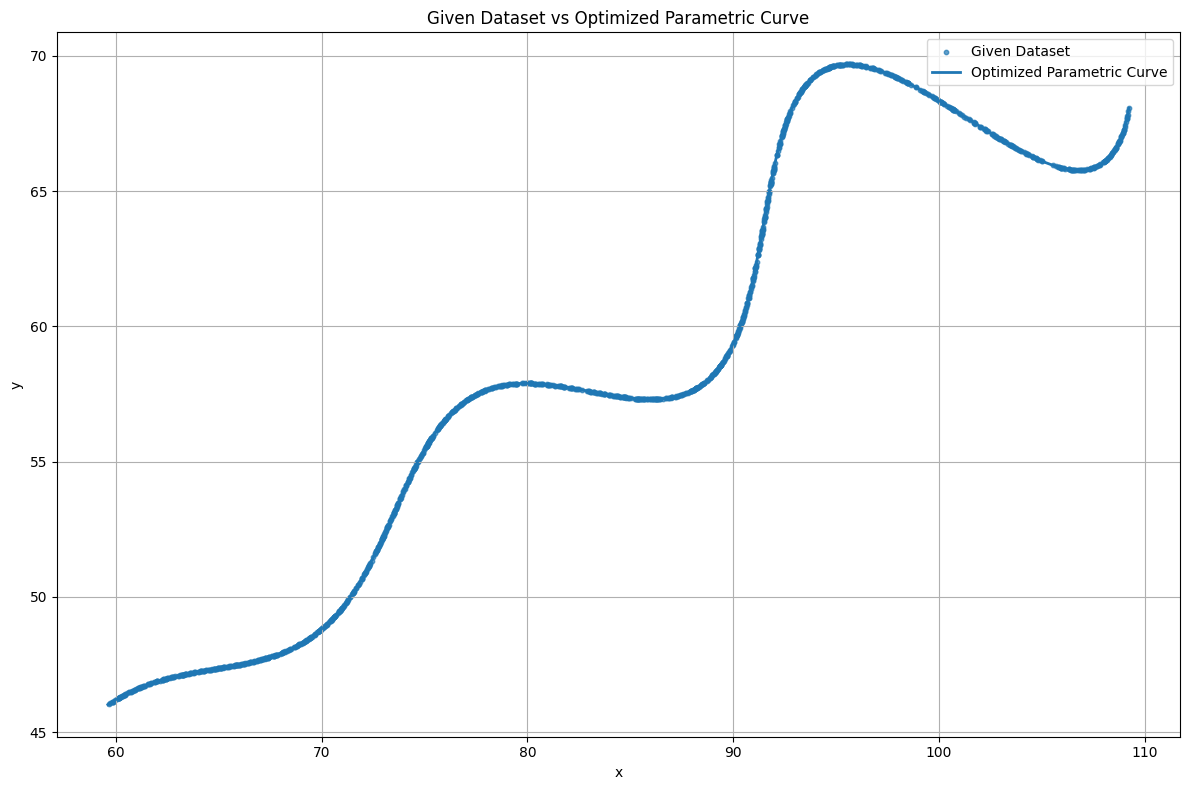

In [15]:
plt.figure(figsize=(12, 8))

# Original dataset
plt.scatter(
    points[:, 0],
    points[:, 1],
    s=10,
    alpha=0.7,
    label="Given Dataset"
)

# Optimized parametric curve
plt.plot(
    optimized_curve[:, 0],
    optimized_curve[:, 1],
    linewidth=2,
    label="Optimized Parametric Curve"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Given Dataset vs Optimized Parametric Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

**Save the visualization**

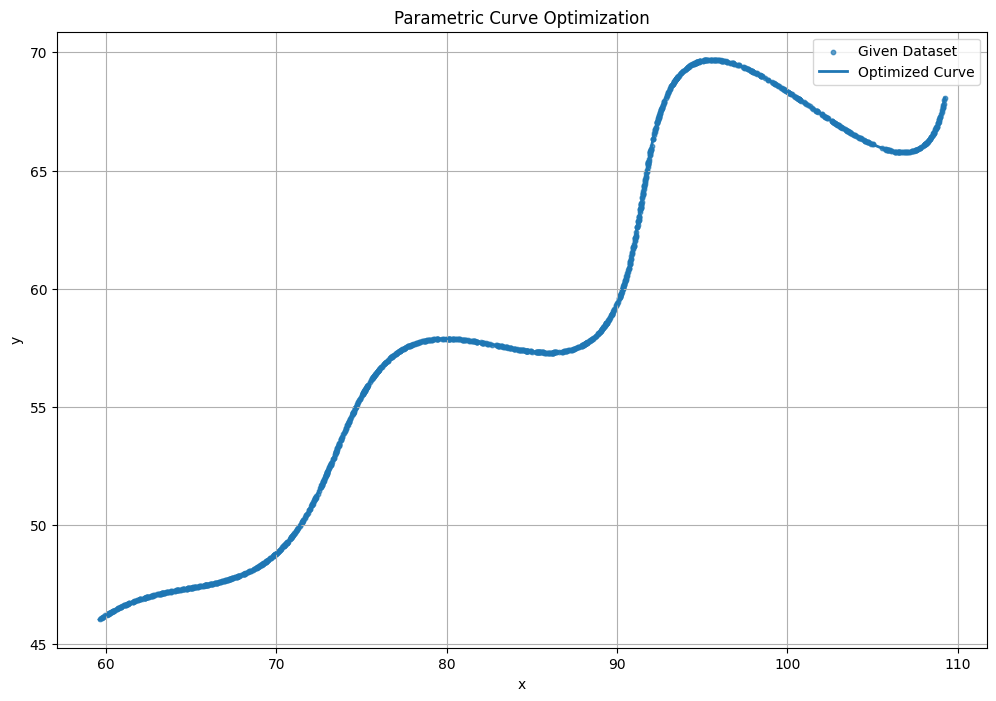

Saved: curve_visualization.png


In [16]:
plt.figure(figsize=(12, 8))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=10,
    alpha=0.7,
    label="Given Dataset"
)

plt.plot(
    optimized_curve[:, 0],
    optimized_curve[:, 1],
    linewidth=2,
    label="Optimized Curve"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Parametric Curve Optimization")

plt.legend()
plt.grid(True)

output_image = "curve_visualization.png"

plt.savefig(
    output_image,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_image)

**Calculate final L1 distances**

In [17]:
tree = cKDTree(optimized_curve)

distances, indices = tree.query(points)

nearest_points = optimized_curve[indices]

l1_distances = np.sum(
    np.abs(points - nearest_points),
    axis=1
)

print("L1 Distance Statistics")
print("=" * 40)

print(f"Mean   : {np.mean(l1_distances):.10f}")
print(f"Median : {np.median(l1_distances):.10f}")
print(f"Minimum: {np.min(l1_distances):.10f}")
print(f"Maximum: {np.max(l1_distances):.10f}")

L1 Distance Statistics
Mean   : 0.0010020874
Median : 0.0009753996
Minimum: 0.0000141862
Maximum: 0.0029675563


**Print the final Desmos equation**

In [18]:
print("=" * 80)
print("DESMOS EQUATION")
print("=" * 80)

desmos_equation = (
    f"(t*cos({theta:.10f})"
    f"-e^({M:.10f}*abs(t))*sin(0.3*t)*sin({theta:.10f})"
    f"+{X:.10f},"
    f"42+t*sin({theta:.10f})"
    f"+e^({M:.10f}*abs(t))*sin(0.3*t)*cos({theta:.10f}))"
    f"{{6<t<60}}"
)

print(desmos_equation)

DESMOS EQUATION
(t*cos(0.5235981308)-e^(0.0299999909*abs(t))*sin(0.3*t)*sin(0.5235981308)+55.0001208584,42+t*sin(0.5235981308)+e^(0.0299999909*abs(t))*sin(0.3*t)*cos(0.5235981308)){6<t<60}


**Download the visualization**

In [19]:
from google.colab import files

files.download("curve_visualization.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Save final results to a text file**

In [20]:
results_text = f"""
PARAMETRIC CURVE OPTIMIZATION RESULTS
=====================================

Theta (radians): {theta:.10f}
Theta (degrees): {theta_degrees:.10f}

M: {M:.10f}

X: {X:.10f}

Mean L1 Distance: {best_loss:.12f}


DESMOS EQUATION
===============

{desmos_equation}
"""

with open("final_results.txt", "w") as file:
    file.write(results_text)

print(results_text)


PARAMETRIC CURVE OPTIMIZATION RESULTS

Theta (radians): 0.5235981308
Theta (degrees): 29.9999630559

M: 0.0299999909

X: 55.0001208584

Mean L1 Distance: 0.002583543462


DESMOS EQUATION

(t*cos(0.5235981308)-e^(0.0299999909*abs(t))*sin(0.3*t)*sin(0.5235981308)+55.0001208584,42+t*sin(0.5235981308)+e^(0.0299999909*abs(t))*sin(0.3*t)*cos(0.5235981308)){6<t<60}



**Download final results**

In [21]:
files.download("final_results.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>